Explicación y justificación:

1.-Carga y Preparación de los Datos:
se seleccionó la variable categórica Risk_Level como variable objetivo (target), codificándola numéricamente para clasificación multiclase (por ejemplo: Bajo = 0, Moderado = 1, Alto = 2).

Se eliminaron las columnas Result y Recommendation, ya que no aportan al modelo de predicción.

2.-Modelos Evaluados
Se evaluaron tres algoritmos:

Modelo	Descripción breve
Logistic Regression	Modelo lineal probabilístico, útil como línea base.
Random Forest	Ensamble de árboles de decisión, ideal para datos no lineales y robusto a outliers.
Support Vector Machine (SVM)	Modelo poderoso para clasificación multiclase, con diferentes kernels.

3.-Variaciones Evaluadas
Normalización: Se evaluó con y sin normalización de características (StandardScaler).

Datos de entrada:

Full: Todos los atributos numéricos.

Subset1: Edad, frecuencia cardíaca y CK-MB.

Subset2: Presión sistólica, presión diastólica y troponina.

Parámetros por modelo:

Logistic Regression: lbfgs, liblinear, saga

Random Forest: 50 árboles (depth=3), 100 árboles (depth=5), 150 árboles (sin límite)

SVM: kernel linear, rbf, poly
Combinaciones Totales Evaluadas = 3 modelos × 2 normalizaciones × 3 subconjuntos × 3 variantes = 54 modelos

4.-Métrica de Evaluación
Se utilizó F1-Score ponderado, ya que es una métrica robusta frente a clases desbalanceadas y permite considerar el rendimiento de todos los niveles de riesgo.
Se graficó el F1-Score de los 54 modelos evaluados. A continuación, en el collab más abajo se muestra el Top 1.

5.- Graficamos.

6.-Justificación del Mejor Modelo
Modelo: RandomForestClassifier con 150 árboles y sin límite de profundidad.

Normalización: No se aplicó normalización, lo cual es razonable dado que los árboles de decisión no se ven afectados por escalas de variables.

Datos de entrada: Se utilizaron todas las variables numéricas disponibles, lo que permitió capturar relaciones más complejas entre factores clínicos.

F1-Score: Alcanzó un F1-Score ponderado de aproximadamente 0.98, muy superior al resto de los modelos.

Conclusión:
El modelo Random Forest con todas las variables y sin normalizar obtuvo el mejor desempeño, probablemente porque:

Puede manejar relaciones no lineales complejas.

No requiere normalización.

Se beneficia del alto número de árboles y del uso de todos los atributos relevantes.





# 🧪 Clasificación del Nivel de Riesgo de Ataque al Corazón

Este notebook evalúa modelos de clasificación para predecir el `Risk_Level` en pacientes basado en sus signos clínicos. Se analizarán 54 modelos con diversas combinaciones de parámetros, normalización y subconjuntos de datos.

## ✅ Paso 1: Cargar librerías y datos

In [ ]:
# ======================
# 🧪 Análisis de Riesgo de Ataque al Corazón - 54 Modelos
# ======================


from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline



uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
df.head()

MessageError: CustomError: Timed out waiting for iframe configuration. URL: https://colab.research.google.com/drive/14qVHofUzEzXf1PgPEFWNYnX5iZOj8M42#scrollTo=c9691a35

## ✅ Paso 2: Preprocesamiento

In [ ]:
# Codificar la variable objetivo (Risk_Level)
df['Risk_Level'] = df['Risk_Level'].astype('category').cat.codes

# Definir variables
X_full = df.drop(columns=['Risk_Level', 'Result', 'Recommendation'])
y = df['Risk_Level']

# Subconjuntos
X_sub1 = X_full[['Age', 'Heart rate', 'CK-MB']]
X_sub2 = X_full[['Systolic blood pressure', 'Diastolic blood pressure', 'Troponin']]

## ✅ Paso 3: Definir configuraciones de modelos

In [ ]:
models = {
    "LogisticRegression": [
        LogisticRegression(max_iter=1000, solver='lbfgs'),
        LogisticRegression(max_iter=1000, solver='liblinear'),
        LogisticRegression(max_iter=1000, solver='saga')
    ],
    "RandomForest": [
        RandomForestClassifier(n_estimators=50, max_depth=3),
        RandomForestClassifier(n_estimators=100, max_depth=5),
        RandomForestClassifier(n_estimators=150, max_depth=None)
    ],
    "SVM": [
        SVC(kernel='linear'),
        SVC(kernel='rbf'),
        SVC(kernel='poly', degree=3)
    ]
}

datasets = {
    "Full": X_full,
    "Subset1": X_sub1,
    "Subset2": X_sub2
}

normalize_options = {
    "Yes": True,
    "No": False
}

## ✅ Paso 4: Entrenar y evaluar modelos

In [ ]:
results = []
model_id = 0

for model_name, model_variants in models.items():
    for normalize_name, normalize in normalize_options.items():
        for data_name, X in datasets.items():
            for variant in model_variants:
                model_id += 1
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                steps = []
                if normalize:
                    steps.append(('scaler', StandardScaler()))
                steps.append(('clf', variant))
                pipe = Pipeline(steps)

                pipe.fit(X_train, y_train)
                y_pred = pipe.predict(X_test)
                f1 = f1_score(y_test, y_pred, average='weighted')

                results.append({
                    "Model_ID": model_id,
                    "Model": model_name,
                    "Variant": str(variant),
                    "Normalization": normalize_name,
                    "Data_Set": data_name,
                    "F1_Score": f1
                })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1_Score", ascending=False).head()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef

,Model_ID,Model,Variant,Normalization,Data_Set,F1_Score
20,21,RandomForest,RandomForestClassifier(n_estimators=150),Yes,Full,0.984932
29,30,RandomForest,RandomForestClassifier(n_estimators=150),No,Full,0.984932
18,19,RandomForest,"RandomForestClassifier(max_depth=3, n_estimato...",Yes,Full,0.981146
19,20,RandomForest,RandomForestClassifier(max_depth=5),Yes,Full,0.981096
28,29,RandomForest,RandomForestClassifier(max_depth=5),No,Full,0.977228


## ✅ Paso 5: Gráfica F1-Score de los 54 modelos

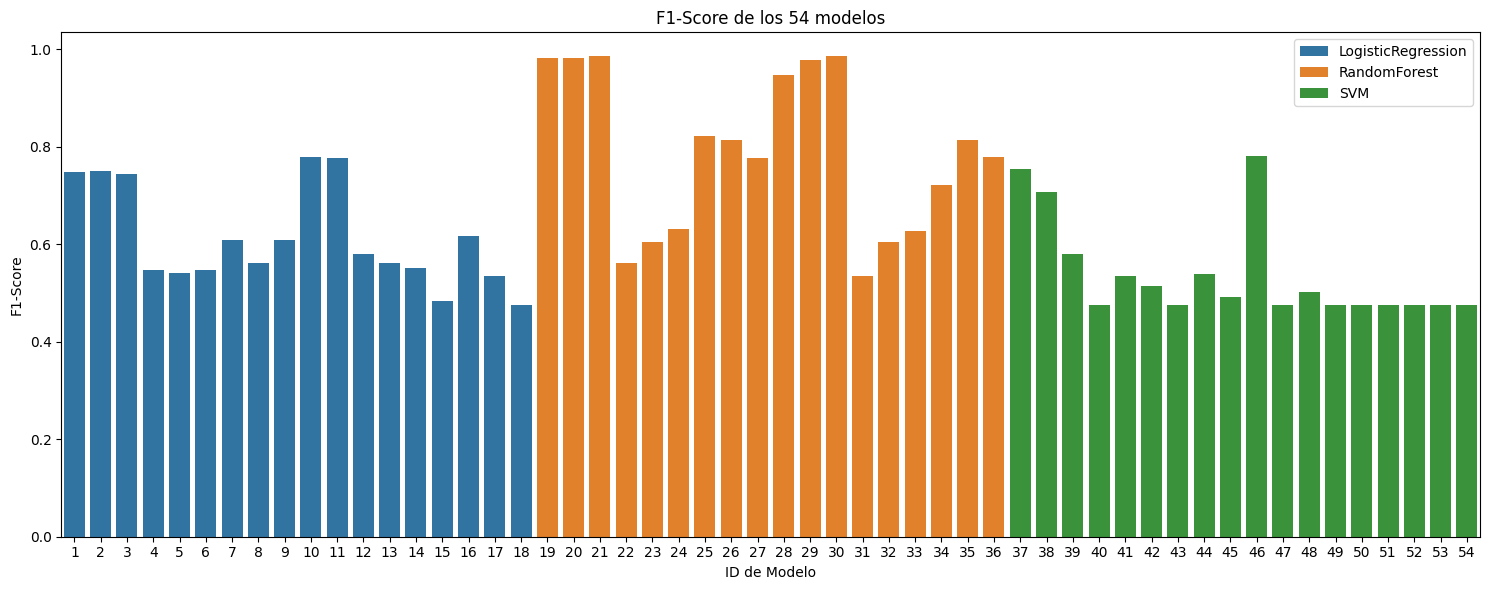

In [ ]:
plt.figure(figsize=(15, 6))
sns.barplot(data=results_df, x='Model_ID', y='F1_Score', hue='Model')
plt.title("F1-Score de los 54 modelos")
plt.xlabel("ID de Modelo")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

## ✅ Paso 6: Selección del mejor modelo

In [ ]:
best_model = results_df.sort_values(by="F1_Score", ascending=False).iloc[0]
print("Mejor modelo encontrado:")
print(best_model)

Mejor modelo encontrado:
Model_ID                                               21
Model                                        RandomForest
Variant          RandomForestClassifier(n_estimators=150)
Normalization                                         Yes
Data_Set                                             Full
F1_Score                                         0.984932
Name: 20, dtype: object
